In [1]:
from pathlib import Path
PROJECT_ROOT = Path("/home/stud/ph/go56sit/go56sit/IceCubeSimulationTheia")
import sys
sys.path.insert(0, str(PROJECT_ROOT / "src"))
import pocam_light
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import hephaistos as hp
#hp.selectDevice(0)
import hephaistos.pipeline as pl
from theia.volume import Attenuating
import theia
import theia.units as u
from pathlib import Path
from theia.compiler import addIncludeDir
import Ice_layers
import material_ice
PROJECT_ROOT = Path(Ice_layers.__file__).resolve().parent.parent
addIncludeDir(PROJECT_ROOT / "shader")
from theia.ray import UnpolarizedRay
from theia.target import SphereTargetGuide
from pocam_light import PocamKapu405WavelengthSource

In [2]:
stack = Ice_layers.LayerStack(PROJECT_ROOT/"IceCube_files/icemodel.dat")

## Parameter für sphereLight

In [3]:
light_position = (46.9072, -56.5889, -385.93)
#wavelength = theia.light.ConstWavelengthSource(405.0 * u.nm)
wavelength = PocamKapu405WavelengthSource() #neu!
medium_idx = stack.get_medium_index(light_position[2])
print(stack.material_store.media["Layer_124"])

125


### Target

In [4]:
targetGuide = SphereTargetGuide(
    position=(31.25, -72.93, -383.40) * u.m,
    radius=0.1651 * u.m,
)

## Paramter für SceneForwardTracer

In [5]:
batchSize = 10_000_000
max_path_length= 50
ray = UnpolarizedRay()
sphereLight = pocam_light.PocamLightSource(
    wavelength,
    mediumIdx=medium_idx,
)


response = theia.response.HistogramHitResponse(
    theia.response.UniformValueResponse(),
    binCount=200,
    binSize= 2.0 * u.ns,
    t0 = 90 * u.ns
)
rng = theia.random.PhiloxRNG(key=0xABBA)
scene = stack.scene

stats = theia.trace.EventStatisticCallback()

In [6]:
sphereTracer = theia.trace.SceneForwardTracer(
    batchSize,
    ray,
    sphereLight,
    response,
    rng,
    scene,
    targetId=1,
    targetGuide=targetGuide,
    maxPathLength=max_path_length,
    callback = stats,
    #DisableTargetSampling = False
)


In [7]:
tasks = [
    ("sphere", {
        "lightSource__budget": 1e10
        
        ,
        "lightSource__position": (
            46.9072,
            -56.5889,
            -385.93,
        ) * u.m,
    }),
]

### Tests 

In [8]:
print(len(stack.instances))#es sollen 171 sein (1 Detektor und 170 boundary planes)

171


In [9]:
print(stack.materials[-1].name) # DOM

DOM


In [10]:
print(stack.instances[-1].material)

DOM


## Submit Work

In [11]:
spherePipeline = pl.Pipeline(sphereTracer.collectStages())

hists = []
def process(config: int, batch: int, args: None) -> None:
    hists.append(response.result(config).copy())


pipelineMap = {
    "sphere": spherePipeline,
}


scheduler = pl.PipelineScheduler(pipelineMap, processFn=process)

scheduler.schedule(tasks)

scheduler.wait()


In [12]:
t = (
    np.arange(response.binCount) * response.binSize + response.t0
) / u.ns

sphereSignal = np.mean(hists[:50], 0)
sphereSignalNorm = sphereSignal/ (
    np.sum(sphereSignal) * response.binSize / u.ns
)


print(f"Batchsize:  {batchSize}")
print(f"MaxPathLength:  {max_path_length}")
print(f"Signal:   {np.sum(sphereSignal)}")
print(stats)

Batchsize:  10000000
MaxPathLength:  50
Signal:   144698.90967596948
 absorbed: 171
  created: 10,000,000
  decayed: 0
 detected: 0
    error: 0
      hit: 0
     lost: 0
  maxIter: 9,999,369
 mismatch: 460
   missed: 0
scattered: 376,618,745
   volume: 93,364,349


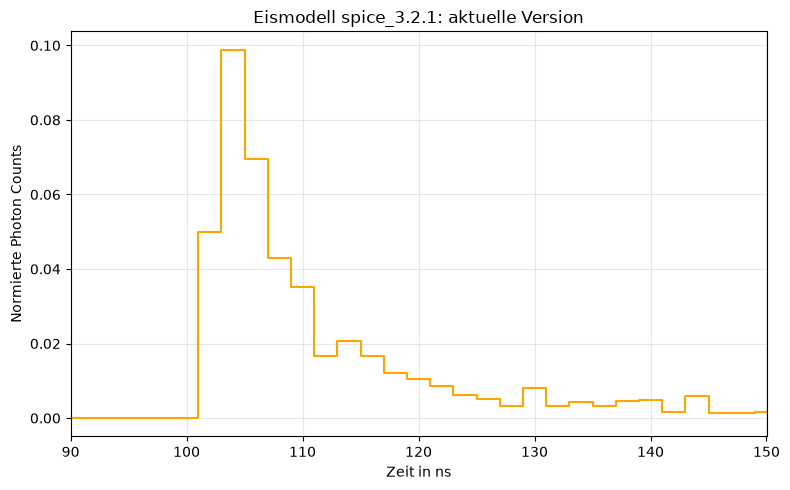

In [13]:
plt.figure(figsize=(8,5))
plt.step(
    t,
    sphereSignalNorm,
    where="mid",
    linewidth=1.5,
    #label=r"",
    color = "orange"
)

plt.xlabel("Zeit in ns")
plt.ylabel("Normierte Photon Counts")
plt.title(r"Eismodell spice_3.2.1: aktuelle Version")
#plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.xlim(90,150)
#plt.legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT/ "Histogramme/aktuelleVersion.pdf")
plt.show()


## IceTray 

IceTray peak density: 0.08963398343574673 ns^-1
Theia peak density: 0.09883985675064076 ns^-1


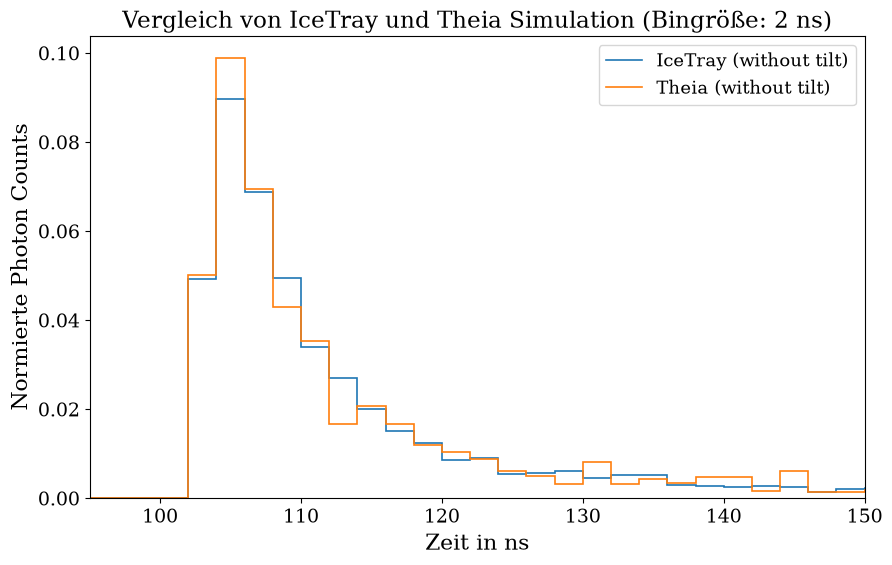

In [14]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "legend.fontsize": 13,
})

t0 = 90.0          # ns
bin_size = 2.0     # ns
bin_count = 200

edges = t0 + np.arange(bin_count + 1) * bin_size
centers = edges[:-1] + 0.5 * bin_size

ice = np.loadtxt(
    "/home/stud/ph/go56sit/go56sit/IceCubeSimulationTheia/IceCube_files/"
    "hist_10000000_100_spice_3.2.1_notilt_2ns.txt"
)

ice_left = ice[:, 0]
ice_right = ice[:, 1]
ice_counts = ice[:, 2]

ice_density = (ice_counts/ np.sum(ice_counts)/ bin_size)

theia_density = (sphereSignal/ np.sum(sphereSignal)/ bin_size)

i_ice = np.argmax(ice_density)
i_theia = np.argmax(theia_density)

print("IceTray peak density:",ice_density[i_ice],"ns^-1")

print("Theia peak density:",theia_density[i_theia], "ns^-1")

plt.figure(figsize=(10, 6))

plt.stairs(
    ice_density,
    edges,
    label="IceTray (without tilt)",
    linewidth=1.2,
)

plt.stairs(
    theia_density,
    edges,
    label="Theia (without tilt)",
    linewidth=1.2,
)

plt.xlabel("Zeit in ns")
plt.ylabel(r"Normierte Photon Counts")

plt.title(
    "Vergleich von IceTray und Theia Simulation "
    "(Bingröße: 2 ns)"
)

plt.xlim(95, 150)

plt.legend()

plt.savefig(
    PROJECT_ROOT / "Histogramme/1VergleichTheiaIceTray_bothwithouttilt.pdf",
    bbox_inches="tight",
)

plt.savefig(
    PROJECT_ROOT / "Histogramme/1VergleichTheiaIceTray_bothwithouttilt.png",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

### Wahrscheinllichkeitsverteilung Tests

In [ ]:
# Test, ob NumericalInversePolynomial die richtige Wahrscheinlichkeitsverteilung samplet

from scipy.stats.sampling import NumericalInversePolynomial
import numpy as np
import matplotlib.pyplot as plt
from pocam_light import _the_pulse

class Dist:
    def pdf(self, x):
        return _the_pulse(x, 15.0) 
                                   #NumericalInversePolynomial() erwartet nämlich ein Objekt das von Dist() erzeugt
                                   #wird und eine Methode pdf(x) besitzt

inv_cdf = NumericalInversePolynomial(
    Dist(),
    domain=(0.0, 120.0),              #erwartet ein Objekt mit Mehode
)
samples = inv_cdf.rvs(size=100000)

plt.figure(figsize=(7,4))

x = np.linspace(0,120,1000)

pdf = _the_pulse(x, 15)
pdf /= np.trapezoid(pdf, x)   # Nomirern!!

plt.hist(samples, bins=100, density=True, alpha=0.5, label="Samples") # density= TRue zur Normierung
plt.plot(x, pdf, label="Normierte PDF")

plt.legend()
plt.show()

In [ ]:
#Test, ob die Pocam-Lightsource funktioniert und Vergl. der Zeiten mit den zeiten der pulse_fkt

import pytest

import numpy as np
import scipy.integrate as integrate
import scipy.stats as stats

import hephaistos as hp
from hephaistos.pipeline import Pipeline, PipelineScheduler, runPipeline
from hephaistos.queue import dumpQueue
from ctypes import Structure, c_float

import theia.light
import theia.units as u
from theia.compiler import compileShader
from theia.material import MaterialStore, PureWaterModel, VACUUM_IDX
from theia.random import PhiloxRNG
from theia.ray import UnpolarizedRay
from theia.testing import BackwardLightSampler

N = 32 * 256
position = (14.0, -2.0, 3.0) * u.m
budget = 12.0

ray = UnpolarizedRay()
philox = PhiloxRNG(key=0xC0110FFC0FFEE)

photons = theia.light.ConstWavelengthSource(
    wavelength=100.0 * u.nm
)

light = pocam_light.PocamLightSource(
    photons,
    position=position,
    budget=budget,
    mediumIdx=VACUUM_IDX,
)

sampler = theia.light.LightSampler(
    N,
    light,
    ray,
    rng=philox,
)

runPipeline(sampler.collectStages())

result = sampler.queue.view(0)

plt.figure(figsize=(8,5))
plt.hist(times, bins=100, density=True, alpha=0.5, label="PocamLightSource")

x = np.linspace(0,120,1000)
pdf = _the_pulse(x,15)
pdf /= np.trapezoid(pdf, x)

plt.plot(x, pdf, lw=2, label=" _the_pulse (normiet)")

plt.legend()
plt.show()


In [ ]:
!git --version